<center>

# **Primera pueba de MLP**

</center>


---

**Autor**: Isaac Yael Cantú Fernández

**Fecha**: 4/2026

> **Librerías**

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

> **Directorio de datos**

In [3]:
path = "/home/icantu24/Documents/ARCHES/data/processed/example";
particles_path = path+"/particles.csv"
shower_path = path+"/shower.csv"

path_prueba = "/home/icantu24/Documents/ARCHES/DAT005000.csv"

> **Dataframe**

In [4]:
particles = pd.read_csv(particles_path)
shower = pd.read_csv(shower_path)
prueba = pd.read_csv(path_prueba)

In [8]:
particles.shower.value_counts()

shower
3939    51301
3920    50028
1212    15400
2027    15333
2882    13077
        ...  
4710        1
4721        1
4878        1
4934        1
4983        1
Name: count, Length: 4977, dtype: int64

In [9]:
len(shower.event_no)

5000

In [5]:
((particles["particle_description"] == prueba["particle_description"]) != True).sum()

np.int64(0)

---

## **Grid**

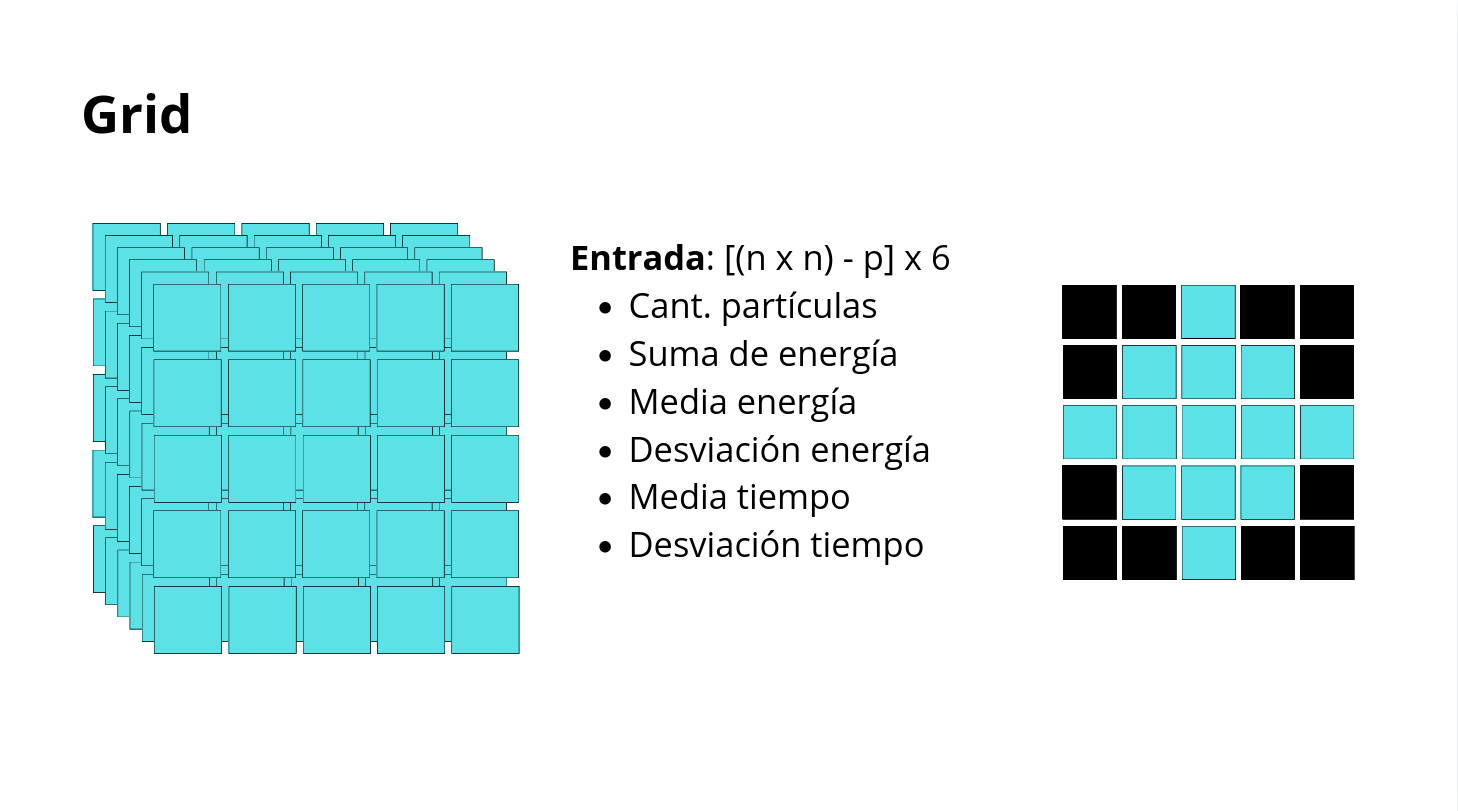

In [5]:
def grid_generator_fast(n=8, df_particles=None, df_shower=None):

    showers = df_particles["shower"].unique()
    n_showers = len(showers)

    # bins espaciales
    
    df = df_particles
    if(False):
        n_sigmas = 3
        x_bins = np.linspace(df_particles["x"].mean() - n_sigmas*np.std(df_particles["x"]), 
                            df_particles["x"].mean() + n_sigmas*np.std(df_particles["x"]), n+1)
        y_bins = np.linspace(df_particles["y"].mean() - n_sigmas*np.std(df_particles["y"]), 
                            df_particles["y"].mean() + n_sigmas*np.std(df_particles["y"]), n+1)
        
    else:   
        # centrar shower
        df_particles["x"] -= df_particles["x"].mean()
        df_particles["y"] -= df_particles["y"].mean()

        # usar percentiles
        x_min, x_max = np.percentile(df_particles["x"], [1, 99])
        y_min, y_max = np.percentile(df_particles["y"], [1, 99])

        x_bins = np.linspace(x_min, x_max, n+1)
        y_bins = np.linspace(y_min, y_max, n+1)

    
    # asignar cada partícula a celda
    df = df_particles.copy()

    df.energy = np.log1p(df.energy)

    df["ix"] = np.digitize(df["x"], x_bins) - 1
    df["iy"] = np.digitize(df["y"], y_bins) - 1

    # mantener solo celdas válidas
    df = df[(df["ix"] >= 0) & (df["ix"] < n) &
            (df["iy"] >= 0) & (df["iy"] < n)]

    # estadísticas por celda
    grouped = df.groupby(["shower", "ix", "iy"])

    stats = grouped.agg(
        count=("energy","size"),
        energy_sum=("energy","sum"),
        energy_mean=("energy","mean"),
        energy_mad=("energy", lambda x: np.mean(np.abs(x - x.mean()))),
        time_mean=("t","mean"),
        time_mad=("t", lambda x: np.mean(np.abs(x - x.mean())))
    ).reset_index()

    # tensor final
    grid_data = np.zeros((n_showers, 6, n, n))

    shower_to_idx = {sh:i for i,sh in enumerate(showers)}

    for _, row in stats.iterrows():

        i = shower_to_idx[row["shower"]]
        j = int(row["ix"])
        k = int(row["iy"])

        grid_data[i,:,j,k] = [
            row["count"],
            row["energy_sum"],
            row["energy_mean"],
            row["energy_mad"],
            row["time_mean"],
            row["time_mad"]
        ]

    output_data = df_shower[df_shower["event_no"].isin(showers)].values

    return grid_data, output_data

grid_data, output_data = grid_generator_fast(n=25, df_particles=particles, df_shower=shower)

In [33]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(grid_data, output_data, train_size=0.7)


(6, 25, 25)

In [35]:
ytrain

array([[ 3.06800000e+03,  1.40000000e+01,  6.65736755e+02, ...,
         3.84547424e+02,  9.54977000e-01,  5.70450000e-02],
       [ 5.80000000e+01,  1.40000000e+01,  4.01487213e+02, ...,
         3.90680023e+02,  2.32538000e-01, -2.11619500e+00],
       [ 3.46800000e+03,  1.40000000e+01,  1.22291885e+02, ...,
         6.21385150e+01,  1.03778300e+00,  2.54469000e+00],
       ...,
       [ 4.49300000e+03,  1.40000000e+01,  1.37861450e+02, ...,
         9.60234300e+01,  8.00236000e-01,  1.78282700e+00],
       [ 4.71700000e+03,  1.40000000e+01,  1.07726288e+02, ...,
         5.68371120e+01,  1.01499200e+00,  2.40468300e+00],
       [ 4.84000000e+02,  1.40000000e+01,  1.76683517e+02, ...,
         1.36477844e+02,  6.88101000e-01,  1.95002000e+00]],
      shape=(3483, 11))

In [ ]:
shower[""]

Index(['event_no', 'particle_id', 'total_energy', 'altitude', 'no_target', 'z',
       'px', 'py', 'pz', 'zenith', 'azimuth'],
      dtype='str')

In [8]:
grid_data.reshape(grid_data.shape[0],6*10*10)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(4977, 600))

In [17]:
particles[particles["shower"]==1]

,shower,particle_type,no_particle,hadr_gen,no_obs,mass,energy,particle_description,px,py,pz,x,y,t
0,1,μ−,6,52,1,0.105658,12.732127,6521,-5.336977,-6.832778,9.323396,-153082.712351,123348.780652,155795.562500
1,1,μ−,6,53,1,0.105658,1.542738,6531,-0.529347,-0.588978,1.319763,163342.443899,426738.257214,147149.296875
2,1,μ−,6,53,1,0.105658,5.683524,6531,-2.054344,-3.307787,4.138780,27601.453665,-18370.699817,156171.250000
3,1,γ,1,99,1,0.000000,0.026479,1991,-0.009340,-0.018759,0.016186,-79480.368601,-11642.185169,157801.671875
4,1,γ,1,99,1,0.000000,0.002923,1991,-0.001302,-0.001356,0.002238,-70671.485788,6793.837292,157295.843750
5,1,γ,1,99,1,0.000000,0.035125,1991,-0.010495,-0.026615,0.020379,-74015.118601,-17143.254505,157881.359375
6,1,μ+,5,52,1,0.105658,17.608009,5521,-6.566347,-10.668100,12.373583,-60866.524851,-132514.367786,159503.859375
7,1,e−,3,99,1,0.000511,0.028936,3991,-0.008693,-0.016057,0.022442,-60878.302195,-132439.414661,159502.687500
8,1,γ,1,2,1,0.000000,0.005250,1021,-0.001417,-0.001066,0.004941,169113.709524,272292.882214,150174.125000
9,1,μ+,5,52,1,0.105658,14.472204,5521,-5.143310,-9.011444,10.088299,-2851.569040,-165816.727161,159453.921875


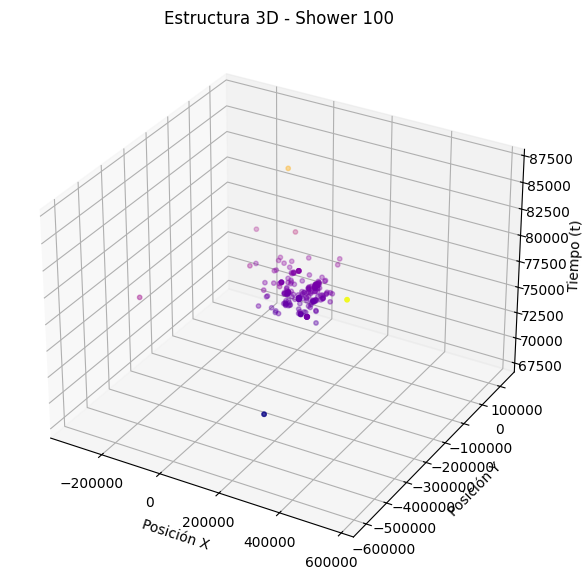

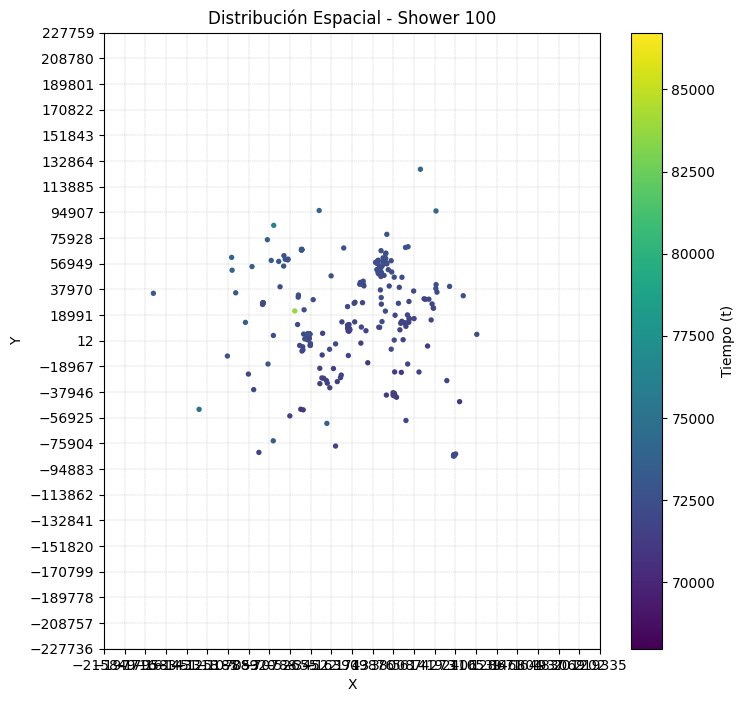

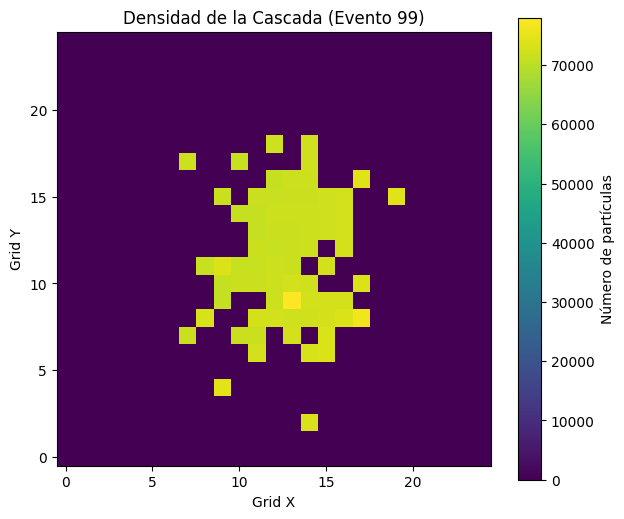

In [49]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

def plot_shower_density(grid_data, event_idx):
    # Canal 0 = conteo de partículas
    density = grid_data[event_idx, 4, :, :] 

    plt.figure(figsize=(7, 6))
    plt.imshow(density, origin="lower", cmap='viridis')
    plt.colorbar(label="Número de partículas")
    
    plt.xlabel("Grid X")
    plt.ylabel("Grid Y")
    plt.title(f"Densidad de la Cascada (Evento {event_idx})")
    plt.show()

# Definir el evento a visualizar
n_shower = 100 
shower_data = particles[particles["shower"] == n_shower]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter3D(shower_data["x"], shower_data["y"], shower_data["t"], 
             c=shower_data["t"], cmap='plasma', s=10)

ax.set_xlabel("Posición X")
ax.set_ylabel("Posición Y")
ax.set_zlabel("Tiempo (t)")
ax.set_title(f"Estructura 3D - Shower {n_shower}")
plt.show()

# Definir límites basados en percentiles para evitar outliers
x_min, x_max = np.percentile(particles["x"], [1, 99])
y_min, y_max = np.percentile(particles["y"], [1, 99])

# Crear bins para el grid
n_bins = 50 # Reducido para mejor visualización del grid
x_bins = np.linspace(x_min, x_max, n_bins + 1)
y_bins = np.linspace(y_min, y_max, n_bins + 1)

plt.figure(figsize=(8, 8))

# Dibujar el grid de fondo de forma más limpia
plt.grid(True, which='major', color='gray', linestyle='--', linewidth=0.3, alpha=0.5)

# Solo mostrar 10 etiquetas en los ejes para que sea legible
plt.xticks(np.linspace(x_min, x_max, 25))
plt.yticks(np.linspace(y_min, y_max, 25))

# Graficar partículas del shower específico
plt.scatter(shower_data["x"], shower_data["y"], 
            c=shower_data["t"], cmap='viridis', s=15, edgecolors='none', label=f'Shower {n_shower}')

plt.colorbar(label="Tiempo (t)")
plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Distribución Espacial - Shower {n_shower}")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

# Llamada final a la función de densidad (usando el mismo evento)
# Nota: Asegúrate de que grid_data esté definido en tu entorno
plot_shower_density(grid_data, n_shower-1)

---

## **Círculos**
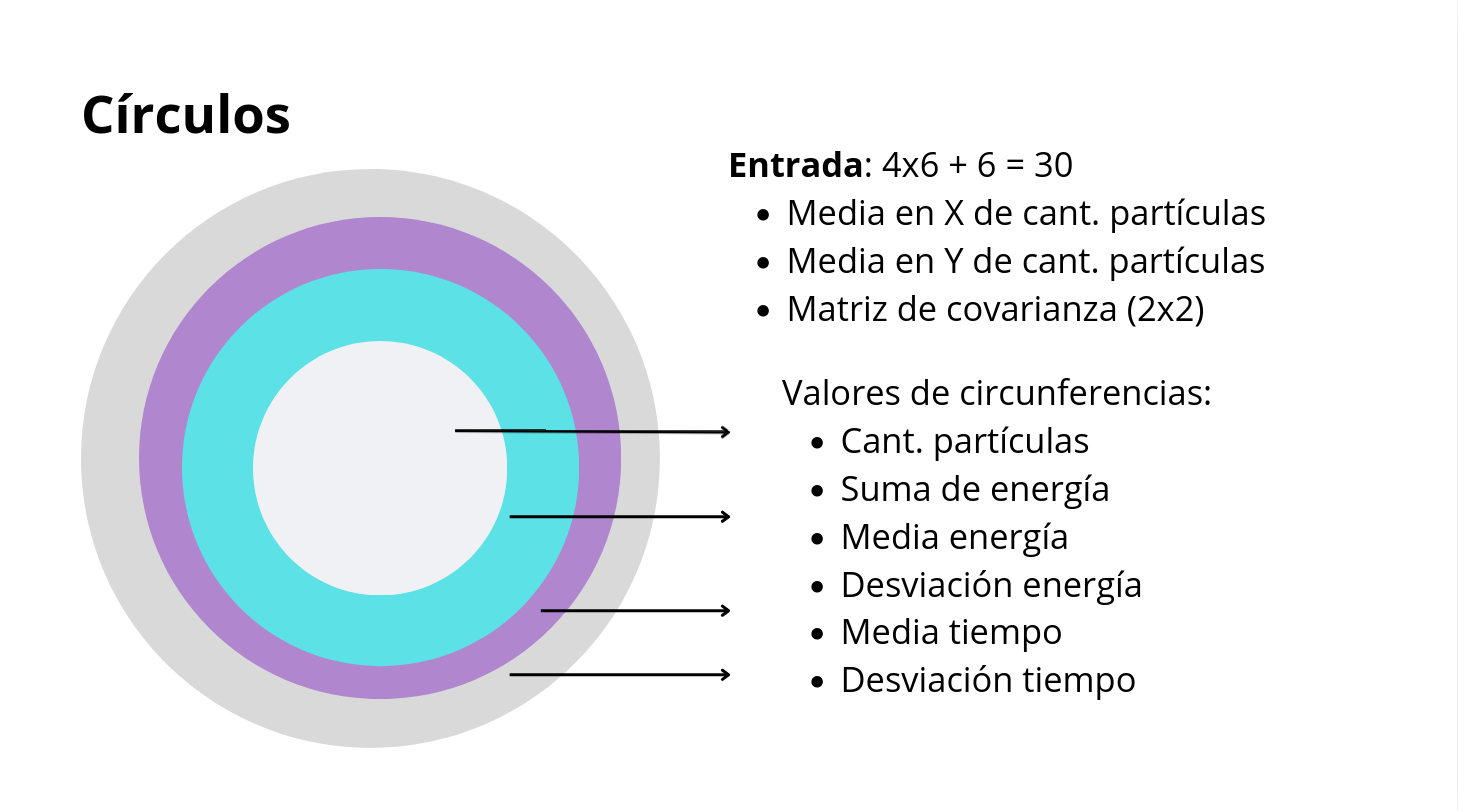

In [7]:
import numpy as np

def circle_generator(df_particles=None, df_shower=None):

    showers = df_particles["shower"].unique()
    n_showers = len(showers)

    circle_data = np.zeros((n_showers, 30))

    for i, shower in enumerate(showers):

        data = df_particles[df_particles["shower"] == shower]

        # -------------------------
        # 1. medias
        # -------------------------
        x_mean = data["x"].mean()
        y_mean = data["y"].mean()

        # -------------------------
        # 2. covarianza
        # -------------------------
        cov = np.cov(data["x"], data["y"])  # 2x2
        cov_flat = cov.flatten()            # 4 valores

        # -------------------------
        # 3. centrar coordenadas
        # -------------------------
        x_c = data["x"] - x_mean
        y_c = data["y"] - y_mean

        r = np.sqrt(x_c**2 + y_c**2)

        # -------------------------
        # 4. sigma radial
        # -------------------------
        sigma = r.std()

        if sigma == 0:
            continue

        r_bins = sigma * np.arange(1,5)

        # -------------------------
        # 5. stats por anillo
        # -------------------------
        features = []

        for j in range(4):

            if j == 0:
                mask = r <= r_bins[j]
            else:
                mask = (r > r_bins[j-1]) & (r <= r_bins[j])

            ring = data[mask]

            if len(ring) == 0:
                features.extend([0]*6)
                continue

            energies = ring["energy"].values
            energies = np.log1p(energies)
            times = ring["t"].values

            features.extend([
                len(ring),
                energies.sum(),
                energies.mean(),
                energies.std(),
                times.mean(),
                times.std()
            ])

        # -------------------------
        # 6. vector final
        # -------------------------
        circle_data[i] = np.concatenate([
            [x_mean, y_mean],
            cov_flat,
            features
        ])

    # -------------------------
    # 7. output (energía)
    # -------------------------
    output_data = df_shower[df_shower["event_no"].isin(showers)].values

    return circle_data, output_data

input, output = circle_generator(particles, shower)

/tmp/ipykernel_23396/4187376389.py:23: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(data["x"], data["y"])  # 2x2
/home/icantu24/Documents/ARCHES/.venv/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/icantu24/Documents/ARCHES/.venv/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [8]:
output.shape

(4977, 11)

x	1.129720e+10	1.329543e+10
y	1.329543e+10	3.583722e+10

In [52]:
np.arange(1,5)

array([1, 2, 3, 4])

In [80]:
particles.groupby("shower")[["x","y"]].std(numeric_only=True).to_numpy()

array([[106288.29730555, 189307.19777801],
       [123864.92305518, 188638.61282406],
       [ 54708.26585814,  55855.17572765],
       ...,
       [183478.82193212, 522904.19956394],
       [165071.46852484, 134019.82258264],
       [137561.95802734, 183035.48384284]], shape=(4977, 2))

In [ ]:
particles.groupby("shower")[["x","y"]].std(numeric_only=True).to_numpy().reshape(-1,2,1)**np.arange(1,5)


array([[[1.06288297e+05, 1.12972021e+10, 1.20076038e+15, 1.27626776e+20],
        [1.89307198e+05, 3.58372151e+10, 6.78424277e+15, 1.28430599e+21]],

       [[1.23864923e+05, 1.53425192e+10, 1.90039996e+15, 2.35392894e+20],
        [1.88638613e+05, 3.55845262e+10, 6.71261567e+15, 1.26625851e+21]],

       [[5.47082659e+04, 2.99299435e+09, 1.63741531e+14, 8.95801520e+18],
        [5.58551757e+04, 3.11980066e+09, 1.74257014e+14, 9.73315613e+18]],

       ...,

       [[1.83478822e+05, 3.36644781e+10, 6.17671878e+15, 1.13329709e+21],
        [5.22904200e+05, 2.73428802e+11, 1.42977069e+17, 7.47633097e+22]],

       [[1.65071469e+05, 2.72485897e+10, 4.49796472e+15, 7.42485642e+20],
        [1.34019823e+05, 1.79613128e+10, 2.40717196e+15, 3.22608759e+20]],

       [[1.37561958e+05, 1.89232923e+10, 2.60312514e+15, 3.58090991e+20],
        [1.83035484e+05, 3.35019883e+10, 6.13205265e+15, 1.12238322e+21]]],
      shape=(4977, 2, 4))

---

## **Estadístico**
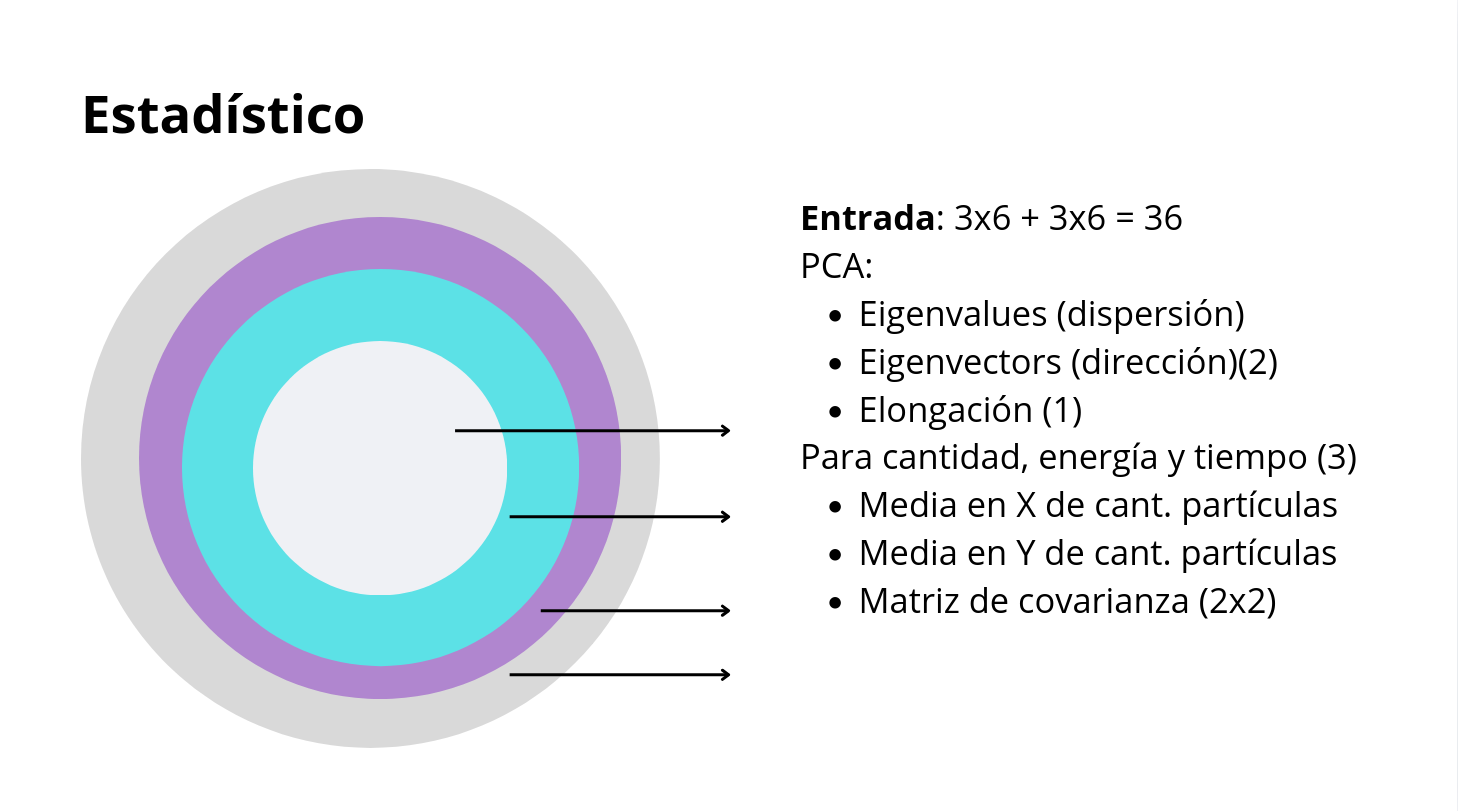

In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import skew

def stats_generator(df_particles=None, df_shower=None):

    showers = df_particles["shower"].unique()
    n_showers = len(showers)

    # 16 features
    stats_data = np.zeros((n_showers, 16))

    for i, shower in enumerate(showers):

        data = df_particles[df_particles["shower"] == shower]

        x = data["x"].values
        y = data["y"].values
        t = data["t"].values
        e = data["energy"].values
        e = np.log1p(e)

        # -------------------------
        # 1. medias espaciales
        # -------------------------
        x_mean = x.mean()
        y_mean = y.mean()
        
        # -------------------------
        # 2. PCA espacial (x,y)
        # -------------------------
        if len(data) >= 2:
            coords = np.vstack((x, y)).T
            coords_scaled = StandardScaler().fit_transform(coords)

            pca = PCA(n_components=2)
            pca.fit(coords_scaled)

            eigenvalues = pca.explained_variance_
            eigenvectors = pca.components_

            lambda1, lambda2 = eigenvalues

            # ángulo del eje principal
            v1 = eigenvectors[0]
            angle = np.arctan2(v1[1], v1[0])  # radianes
        else:
            # Fallback for showers with only 1 particle
            lambda1, lambda2, angle = 0.0, 0.0, 0.0

        # ángulo del eje principal
        v1 = eigenvectors[0]
        angle = np.arctan2(v1[1], v1[0])  # radianes

        # -------------------------
        # 3. tiempo
        # -------------------------
        t_mean = t.mean()
        t_std = t.std()
        t_skew = skew(t) if len(t) > 2 else 0

        # -------------------------
        # 4. energía
        # -------------------------
        e_sum = e.sum()
        e_mean = e.mean()
        e_var = e.var()
        e_max = e.max()

        # -------------------------
        # 5. covarianzas
        # -------------------------
        cov_xt = np.cov(x, t)[0,1] if len(x) > 1 else 0
        cov_yt = np.cov(y, t)[0,1] if len(y) > 1 else 0

        # -------------------------
        # 6. radio
        # -------------------------
        r = np.sqrt((x - x_mean)**2 + (y - y_mean)**2)

        r_mean = r.mean()
        r_var = r.var()

        # -------------------------
        # vector final
        # -------------------------
        stats_data[i] = [
            x_mean,
            y_mean,
            lambda1,
            lambda2,
            angle,
            t_mean,
            t_std,
            t_skew,
            e_sum,
            e_mean,
            e_var,
            e_max,
            cov_xt,
            cov_yt,
            r_mean,
            r_var
        ]

    # -------------------------
    # target
    # -------------------------
    output_data = df_shower[
        df_shower["event_no"].isin(showers)
    ].values

    return stats_data, output_data

input, output = stats_generator(particles, shower)

In [6]:
output

array([[ 1.00000000e+00,  1.40000000e+01,  2.94369263e+02, ...,
         2.12764114e+02,  7.62975000e-01, -2.14180600e+00],
       [ 2.00000000e+00,  1.40000000e+01,  1.01485573e+02, ...,
         8.30694810e+01,  6.11880000e-01,  1.57311600e+00],
       [ 3.00000000e+00,  1.40000000e+01,  1.91815186e+02, ...,
         1.23195061e+02,  8.73344000e-01, -2.55655400e+00],
       ...,
       [ 4.99800000e+03,  1.40000000e+01,  1.05404510e+02, ...,
         6.15663150e+01,  9.47002000e-01, -1.41604500e+00],
       [ 4.99900000e+03,  1.40000000e+01,  2.46287338e+02, ...,
         2.25831818e+02,  4.10425000e-01, -2.36697100e+00],
       [ 5.00000000e+03,  1.40000000e+01,  1.25061676e+02, ...,
         1.18630661e+02,  3.22001000e-01,  1.12304200e+00]],
      shape=(4977, 11))

In [ ]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# 1. Crear datos de ejemplo con grupos
data = {
    'grupo': ['A', 'A', 'A', 'B', 'B', 'C', 'D', 'D', 'E', 'E'],
    'feature': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'target': [0, 0, 1, 1, 0, 1, 0, 1, 1, 0]
}
df = pd.DataFrame(data)

# 2. Definir características (X), objetivo (y) y grupos
X = df[['feature']]
y = df['target']
groups = df['grupo']

# 3. Configurar GroupShuffleSplit (ej. 80% train, 20% test)
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)

# 4. Generar los índices
train_idx, test_idx = next(gss.split(X, y, groups))

# 5. Crear conjuntos finales
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train Groups:", df['grupo'].iloc[train_idx].unique())
print("Test Groups:", df['grupo'].iloc[test_idx].unique())


Dirección principal (Vector): [0.70710678 0.70710678]
Ángulo de la dirección: 45.00 grados
Relación de Elongación (PC1/PC2): 10.68


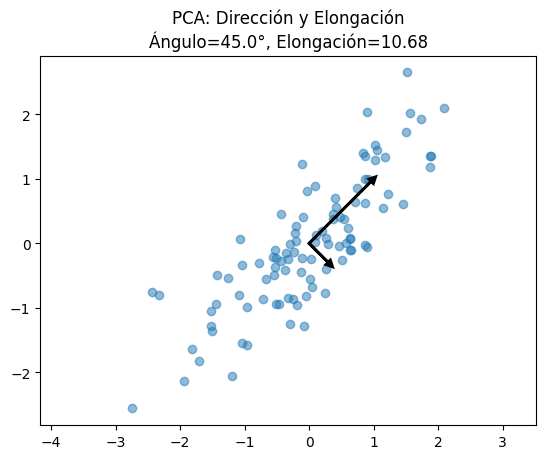

In [96]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Crear datos de ejemplo (una elipse/forma elongada)
np.random.seed(42)
n_samples = 100
# Datos centrados
x = np.random.normal(0, 2, n_samples)
y = np.random.normal(0, 0.5, n_samples)
# Rotar los datos
theta = np.radians(30)
c, s = np.cos(theta), np.sin(theta)
R = np.array(((c, -s), (s, c)))
data = np.dot(np.array([x, y]).T, R.T)

# 2. Estandarizar los datos (Media 0, Desviación Estándar 1) - RECOMENDADO
from sklearn.preprocessing import StandardScaler
data_scaled = StandardScaler().fit_transform(data)

# 3. Aplicar PCA
pca = PCA(n_components=2)
pca.fit(data_scaled)

# 4. Obtener Dirección y Elongación
# Componentes (Direcciones principales)
componentes = pca.components_
# Varianza explicada (autovalores simplificados)
varianza = pca.explained_variance_ 

# --- Interpretación ---
# Dirección: Componente 1 (primera fila de components_)
direccion_principal = componentes[0]
angulo = np.degrees(np.arctan2(direccion_principal[1], direccion_principal[0]))

# Elongación (Relación entre varianza del 1er y 2do componente)
elongacion = varianza[0] / varianza[1]

print(f"Dirección principal (Vector): {direccion_principal}")
print(f"Ángulo de la dirección: {angulo:.2f} grados")
print(f"Relación de Elongación (PC1/PC2): {elongacion:.2f}")

# 5. Visualización
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], alpha=0.5)
for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    # Dibujar vectores propios escalados por su varianza
    plt.arrow(0, 0, comp[0]*np.sqrt(var), comp[1]*np.sqrt(var), 
              head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=2)
plt.title(f'PCA: Dirección y Elongación\nÁngulo={angulo:.1f}°, Elongación={elongacion:.2f}')
plt.axis('equal')
plt.show()


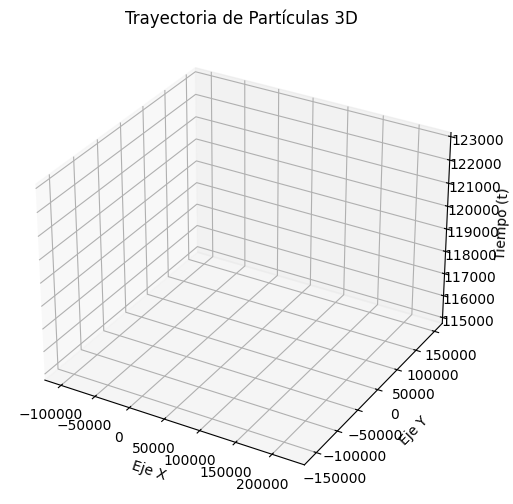

In [108]:
# 1. Habilitar el backend interactivo para Jupyter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Supongamos que df3d ya existe en tu contexto
df3d = particles[particles.shower == 1000]

# Extraer datos
z = df3d.t.values
x = df3d.x.values
y = df3d.y.values

# Configuración de la figura
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Inicializar el objeto scatter vacío para actualizarlo luego
graph = ax.scatter([], [], [], c='blue', s=10)

# Configurar límites y etiquetas (se hace una sola vez, no en el update)
ax.set_xlim(min(x), max(x))
ax.set_ylim(min(y), max(y))
ax.set_zlim(min(z), max(z))
ax.set_xlabel("Eje X")
ax.set_ylabel("Eje Y")
ax.set_zlabel("Tiempo (t)")
ax.set_title("Trayectoria de Partículas 3D")

def update(num):
    """
    Función que se ejecuta en cada frame.
    'num' es el índice del frame actual.
    """
    # Actualizamos los datos hasta el frame actual para ver el rastro
    graph._offsets3d = (x[:num], y[:num], z[:num])
    return graph,

# Crear la animación
# frames=len(z) define cuántos pasos tendrá la animación
ani = FuncAnimation(fig, update, frames=len(z), interval=50, blit=False)

plt.show()